<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# CMSE 801 - Day 24
## Using random numbers for numerical solutions and optimization
### Application: The Traveling Salesperson Problem
#### April 14, 2024

## General Course Announcements

* Final version of your project notebook is due **April 20 by 11:59pm**.
    * We will assign presentation days on **today** using a random number generator.
* You can continue to work on your slides after that deadline and up until you present.
* Quiz 4 grades to be uploaded later today.
* Homework 5 is due **Saturday, April 18, by 11:59pm**.

## Let's assign presentation days!

In [1]:
import numpy as np
import pandas as pd

roster = pd.read_csv("SS26-CMSE-801.csv")
all_names = roster['Name']
print(all_names)

0                            Nimtz, William
1                             Kepros, Ethan
2                          Dittman, Michael
3                                 Dong, Xin
4                          Matlock, Dashiel
5                               Bajcz, Jack
6                                   Hu, Sam
7                               Hortop, Max
8                           Garcia, Lautaro
9                          Lover, Alexander
10    El Habet, Mohamed Abdulazim Ali Afifi
11                            Vajire, Sujal
12                             Rai, Abraham
13                   Blanco Casallas, Irene
14                         Goodluck, Samuel
15                           Akintan, Grace
16                         Mamtani, Saksham
17                     Bekbulatkyzy, Aidana
18                         Meherin, Sanjida
19                           Duran, Jessica
20                                 Zhou, Mi
21                               Ge, Jingyi
22                         AlMah

In [2]:
pre_excused_day1 = []
pre_excused_day2 = ["AlMahmood, Basma"]
# Remove anyone who was pre-excused from Day 1 or Day 2
# (since they need to be assigned by hand)
all_names = all_names.tolist()

for s in (pre_excused_day1 + pre_excused_day2):
    if s in all_names:
        all_names.remove(s)

In [3]:

        
#### Choose who will present on the Day 1 ####

# Define an array for storing presenter names
day1 = np.array([])

# Add in anyone excused from Day 2 to ensure they present on Day 1
day1 = np.append(day1,pre_excused_day2)
    
# Now we pick half class people to present on Day 1
pick_Day1 = np.random.choice(all_names, 13, replace=False)

# Append the picks to the first array
day1 = np.append(day1,pick_Day1)

# Shuffle the students to determine presentation order
np.random.shuffle(day1)

# Print and store the results for Day 1
print("The following students will present on Day 1 (April 21):\n")
day1_with_order = []
count = 0
for i,student in enumerate(day1):
    count += 1
    print("%i" %(count),student)
    day1_with_order.append("%i %s" %(count,student))
    
#### Choose who will present on Day 2 ###

# Assign all the remaining students to Day 2:
day2 = []
for student in all_names:
    if student not in day1:
        day2.append(student)
        
# Add in anyone excused from Day 1
day2 = np.append(day2,pre_excused_day1)

# Shuffle the student determine the presentation order
np.random.shuffle(day2)

# Print and store the results for Day 2
print("\nThe following students will present on Day 2 (April 23):\n")
day2_with_order = []
count = 0
for i,student in enumerate(day2):
    count += 1
    print("%i" %(count),student)
    day2_with_order.append("%i %s" %(count,student))
        
# Check for potential duplicates (in case a mistake was made)
for student in day1:
    if student in day2:
        print(student)

The following students will present on Day 1 (April 21):

1 Meherin, Sanjida
2 Hortop, Max
3 Bekbulatkyzy, Aidana
4 Rai, Abraham
5 Islam, Md Shariful
6 Tran, Andrew
7 Kepros, Ethan
8 Bajcz, Jack
9 Goodluck, Samuel
10 AlMahmood, Basma
11 Tian, Lin
12 Duran, Jessica
13 Blanco Casallas, Irene
14 Akintan, Grace

The following students will present on Day 2 (April 23):

1 Hu, Sam
2 Dittman, Michael
3 Lover, Alexander
4 Nimtz, William
5 Matlock, Dashiel
6 Zhou, Mi
7 Garcia, Lautaro
8 El Habet, Mohamed Abdulazim Ali Afifi
9 Ge, Jingyi
10 Mamtani, Saksham
11 Mercer, Madison
12 Vajire, Sujal
13 Dong, Xin


In [4]:
# Save the results to a file
f = open("CMSE801-presentations-SS26.txt", "w+")

f.write("The following students will present on Day 1 (April 21):\n\n")
for s in day1_with_order:
    f.write("%s \n" %s)
f.write("\n")

f.write("=====================================================================\n")

f.write("The following students will present on Day 2 (April 23):\n\n")
for s in day2_with_order:
    f.write("%s \n" %s)
f.write("\n")
        
f.close()

## Questions/comments from Day 24 PCA

* Some challenges with the distance calculation and then feeding that into the final animation

## Solving problems with random numbers

* Random numbers can be used to find solutions to problems that would either take too long to solve exactly, or have no exact solutions.
* The traveling salesperson problem is a good example of this -- testing every single possible route can take a _very long time_.
    * For $20$ cities, this would require $2,432,902,008,176,640,000$ (approximately $2.4 \times 10^{18}$) tests - if you could test one combination per microsecond ($10^{-6}$ s) it would take approximately 76,000 years!
* Using random numbers we can try to find a "good enough" solution.

## Using random numbers to evaluate integrals

Let's find the solution to this integral, numerically: $$y = \sqrt{1 - x^2}$$

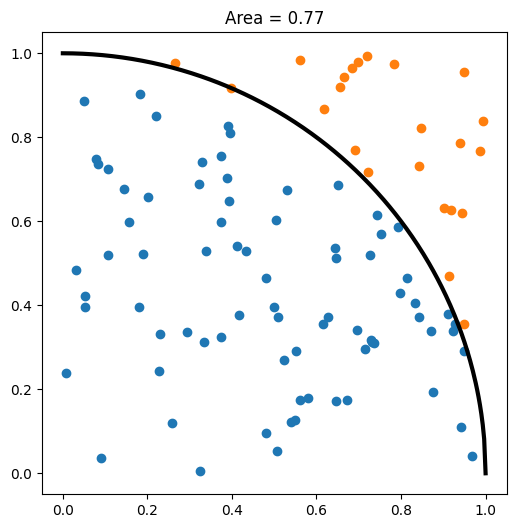

Area = 0.77
Real area = 0.7853981633974483


<Figure size 600x600 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import random
import numpy as np
from IPython.display import display, clear_output
import time
import random

# Set up the figure
fig = plt.figure(figsize=(6,6))

# How many points will we drop on the graph?
npoints = 100

# Set up variables for keeping track of points
is_in = 0
is_out = 0
x_in = []
y_in = []
x_out = []
y_out = []

for i in range(npoints):
    # Draw a point at random
    x = random.random()
    y = random.random()
    
    # Check is the point is inside or outside the curve
    if y < np.sqrt(1-x**2):
        is_in += 1
        x_in.append(x)
        y_in.append(y)
    else:
        is_out += 1
        x_out.append(x)
        y_out.append(y)
    
    # Plot the point
    plt.scatter(x_in,y_in)
    plt.scatter(x_out,y_out)
    
    x = np.linspace(0,1,300)
    y = np.sqrt(1-x**2)
    # Plot the curve
    plt.plot(x,y,lw=3,c='k')
    
    # Calculate estimated value of the integral
    plt.title("Area = %0.2f" %(is_in/npoints))
    
#     time.sleep(0.1)  
    clear_output(wait = True)
    display(fig)            # Reset display
    fig.clear()

print("Area =", is_in/npoints)
print("Real area =", np.pi/4.0)

## Setting up "cities" for the salesperson

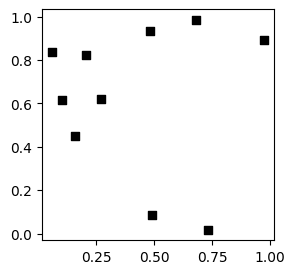

In [7]:
def create_cities(n_city):
    x_loc = np.random.random(n_city)
    y_loc = np.random.random(n_city)
    return x_loc,y_loc

n_city = 10
x,y = create_cities(n_city)
plt.figure(figsize=(3,3))
plt.scatter(x,y,marker="s",c="k");

## Create a distance matrix

In [8]:
def calculate_distances(x_loc, y_loc):
    D = np.zeros((len(x_loc), len(y_loc)))
    for i in range(D.shape[0]):
        this_x = x_loc[i]
        this_y = y_loc[i]
        for j in range(D.shape[1]):
             D[i,j] = np.sqrt((x_loc[j]-this_x)**2 + (y_loc[j]-this_y)**2)
    return D

n_city = 5
x,y = create_cities(n_city)
D = calculate_distances(x,y)
print(D)

[[0.         0.44098074 1.09906288 0.84579992 1.10389251]
 [0.44098074 0.         0.77443421 0.89910885 0.73104659]
 [1.09906288 0.77443421 0.         0.82540221 0.16491109]
 [0.84579992 0.89910885 0.82540221 0.         0.95278743]
 [1.10389251 0.73104659 0.16491109 0.95278743 0.        ]]


## Wander through the cities in order

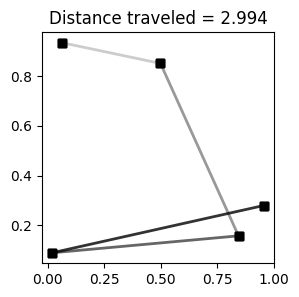

<Figure size 300x300 with 0 Axes>

In [9]:
fig = plt.figure(figsize=(3,3));
total_distance = 0
for i in range(n_city-1):
    plt.scatter(x,y,marker="s",c="k");
    plt.plot([x[i],x[i+1]], [y[i],y[i+1]],
             alpha=(i+1)/(n_city),lw=2,color="k");
    total_distance += D[i,i+1]
    plt.title("Distance traveled = %0.3f" %total_distance)
    time.sleep(1.0)  
    clear_output(wait = True)
    display(fig) # Reset display
fig.clear()

## Goals for today
* Use randomness to "guess" your ways to shortest route for a traveling salesperson
* Visualize your progress towards finding the "best" solution (within computational reason)

## Looking forward - Day 25 PCA: Revisiting fitting models to data

* Remind ourselves what it means to find a goodness of fit
* Explore the "chi-squared" method of determine goodness of fit
* Perform a "grid search" to find best fit parameters
